In [20]:
import pandas as pd
import random
import os
import matplotlib.pyplot as plt
import numpy as np

### Download prokaryotic database and info

https://zenodo.org/records/10457006

    VMGC_prokaryote_MAG.info

    VMGC_prokaryote_MAG.tar.gz

    VMGC_prokaryote_SGB.info

### Make genomes.tsv file for MIDAS input


Needs columns: genome, species, representative, genome_is_representative

In [2]:
df = pd.read_csv('VMGC_orig_files/VMGC_prokaryote_MAG.info', sep='\t')

In [3]:
df.head()

,Genome_ID,BioSample_ID,Collection/isolation_source,Type,Genome_size_(bp),No._of_contigs,N50_length_(bp),N90_length_(bp),Max_length_(bp),%_GC_content,%_Completeness,%_Contamination,Quality_score,Clade_separation_score_(GUNC),Presence_of_5S_rRNA,Presence_of_16S_rRNA,Presence_of_23S_rRNA,No._of_tRNA,Genome_quality,Species-level_genomic_bin_(95%_ANI)
0,ERR10897564.mbin.1,ERR10897564,vaginal swab,MAG,1087166,64,21321,9170,106681,32.47,92.37,0.36,90.57,0.00,Y,N,N,16,high-quality,SGB001
1,ERR10897570.mbin.1,ERR10897570,vaginal swab,MAG,946879,36,35494,16114,91025,44.15,69.36,0.05,69.11,0.03,N,N,N,14,medium-quality,SGB020
2,ERR10897572.mbin.2,ERR10897572,vaginal swab,MAG,634492,160,4095,2310,18976,32.86,51.82,0.05,51.57,0.00,Y,N,N,12,medium-quality,SGB001
3,ERR10897572.mbin.3,ERR10897572,vaginal swab,MAG,1042602,73,18747,7657,84304,37.32,59.34,0.17,58.49,0.00,N,N,N,16,medium-quality,SGB006
4,ERR10897573.mbin.4,ERR10897573,vaginal swab,MAG,2066518,406,5736,2674,38890,42.40,75.82,1.43,68.67,0.00,N,N,N,16,medium-quality,SGB014


In [4]:
len(df['Genome_ID'].unique()), df.shape[0]

(19542, 19542)

In [5]:
sgb = pd.read_csv('VMGC_orig_files/VMGC_prokaryote_SGB.info', sep='\t', index_col=0)
sgb = sgb.rename(columns={'Representative_genome_ID':'VMGC_representative',
                         'Species':'species_name'})


In [6]:
sgb.shape

(786, 11)

In [7]:
sgb.head()

,VMGC_representative,Number_of_genomes,Kingdom,Phylum,Class,Order,Family,Genus,species_name,Taxonomic_level,Cultured
SGB_ID,,,,,,,,,,,
SGB001,SRR17284223.mbin.1,1544,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Lactobacillus,Lactobacillus iners,Species,Cultured (women vagina)
SGB002,GCF_001562845.1,764,Bacteria,Actinomycetota,Coriobacteriia,Coriobacteriales,Atopobiaceae,Fannyhessea,Fannyhessea vaginae,Species,Cultured (women vagina)
SGB003,GCF_001553395.1,664,Bacteria,Bacillota_C,Negativicutes,Veillonellales,Megasphaeraceae,Megasphaera,Megasphaera lornae,Species,Cultured (women vagina)
SGB004,ERR10897722.mbin.1,586,Bacteria,Actinomycetota,Actinomycetia,Actinomycetales,Bifidobacteriaceae,Bifidobacterium,Bifidobacterium vaginale,Species,Cultured (women vagina)
SGB005,MG1112.mbin.9,562,Bacteria,Actinomycetota,Actinomycetia,Actinomycetales,Bifidobacteriaceae,Bifidobacterium,Bifidobacterium swidsinskii,Species,Cultured (women vagina)


In [8]:
genomes = df[['Genome_ID','Species-level_genomic_bin_(95%_ANI)', 'Quality_score', 'Genome_quality']]
genomes = genomes.rename(columns={'Genome_ID':'genome', 'Species-level_genomic_bin_(95%_ANI)':'SGB'})
genomes = genomes.merge(sgb[['VMGC_representative','species_name']], left_on='SGB', right_index=True)
# genomes = genomes.merge(sgb[['species_name']], left_on='SGB', right_index=True)

genomes

,genome,SGB,Quality_score,Genome_quality,VMGC_representative,species_name
0,ERR10897564.mbin.1,SGB001,90.57,high-quality,SRR17284223.mbin.1,Lactobacillus iners
1,ERR10897570.mbin.1,SGB020,69.11,medium-quality,ERR10897780.mbin.8,Bifidobacterium vaginale_C
2,ERR10897572.mbin.2,SGB001,51.57,medium-quality,SRR17284223.mbin.1,Lactobacillus iners
3,ERR10897572.mbin.3,SGB006,58.49,medium-quality,GCF_000162255.1,Lactobacillus crispatus
4,ERR10897573.mbin.4,SGB014,68.67,medium-quality,P10708985.mbin.1,Prevotella timonensis_A
...,...,...,...,...,...,...
19537,SRR6748217.mbin.3,SGB026,56.17,medium-quality,SRR13167550.mbin.1,Bifidobacterium piotii
19538,SRR6748218.mbin.1,SGB025,58.70,medium-quality,MG238.mbin.3,Prevotella bivia
19539,SRR6748219.mbin.1,SGB004,96.64,high-quality,ERR10897722.mbin.1,Bifidobacterium vaginale
19540,GCF_029101565.1,SGB009,90.39,near-complete,GCF_029101565.1,Amygdalobacter indicium (BVAB2)


### Group by GTDB species

In [9]:
sp_list = genomes['species_name'].unique()

In [10]:
len(sp_list)

544

In [11]:
#randomly assign 6 digit numbers to species

random.seed(1)
nums = random.sample(range(100000,999999), len(sp_list))

sp_to_nums = {sp_list[i]:nums[i] for i in range(len(sp_list))}

In [12]:
genomes['species'] = genomes['species_name'].map(sp_to_nums)

In [13]:
genomes

,genome,SGB,Quality_score,Genome_quality,VMGC_representative,species_name,species
0,ERR10897564.mbin.1,SGB001,90.57,high-quality,SRR17284223.mbin.1,Lactobacillus iners,240891
1,ERR10897570.mbin.1,SGB020,69.11,medium-quality,ERR10897780.mbin.8,Bifidobacterium vaginale_C,696853
2,ERR10897572.mbin.2,SGB001,51.57,medium-quality,SRR17284223.mbin.1,Lactobacillus iners,240891
3,ERR10897572.mbin.3,SGB006,58.49,medium-quality,GCF_000162255.1,Lactobacillus crispatus,988598
4,ERR10897573.mbin.4,SGB014,68.67,medium-quality,P10708985.mbin.1,Prevotella timonensis_A,941235
...,...,...,...,...,...,...,...
19537,SRR6748217.mbin.3,SGB026,56.17,medium-quality,SRR13167550.mbin.1,Bifidobacterium piotii,595185
19538,SRR6748218.mbin.1,SGB025,58.70,medium-quality,MG238.mbin.3,Prevotella bivia,900875
19539,SRR6748219.mbin.1,SGB004,96.64,high-quality,ERR10897722.mbin.1,Bifidobacterium vaginale,783244
19540,GCF_029101565.1,SGB009,90.39,near-complete,GCF_029101565.1,Amygdalobacter indicium (BVAB2),567022


In [46]:
sum(genomes.value_counts('species') >= 2)

308

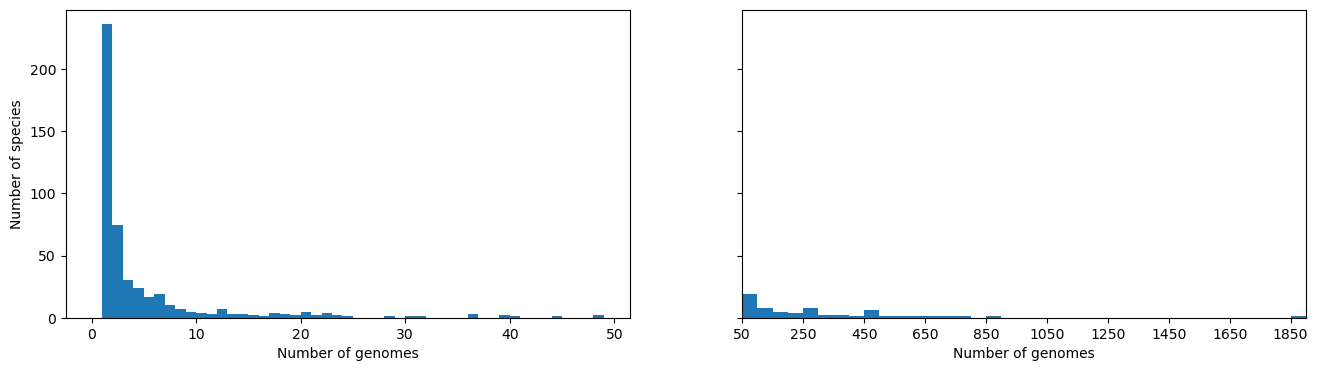

In [43]:
fig, ax = plt.subplots(1,2, figsize=(16,4), sharey=True)

ax[0].hist(genomes['species'].value_counts(), bins= np.arange(0,50, 1))
ax[0].set_xlabel('Number of genomes')
ax[0].set_ylabel('Number of species')

ax[1].hist(genomes['species'].value_counts(), bins= np.arange(50,2000, 50))
ax[1].set_xlim(50, 1900)
ax[1].set_xlabel('Number of genomes')
# ax[1].set_ylabel('Number of species')
ax[1].set_xticks(np.arange(50, 2000, 200))


In [14]:
genomes = genomes[['genome','species', 'SGB', 'species_name', 'Quality_score', 'Genome_quality','VMGC_representative']]

### Assign representative for each species

For VMGC: For each SGB, MAGs are sorted in the order of quality groups: near-complete, high-quality and medium-quality. Within each group, they are further sorted based on the genome quality score from high to low. The top-ranked MAG was considered as the reference genome for the corresponding SGB.

In [394]:
genomes['genome_is_VMGC_representative'] = (genomes['genome'] == genomes['VMGC_representative']).astype(int)


/var/folders/xx/th7rx6l128qdnxdzd6bxqydw0000gn/T/ipykernel_63248/2775254861.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genomes['genome_is_VMGC_representative'] = (genomes['genome'] == genomes['VMGC_representative']).astype(int)


In [396]:
genomes['Genome_quality'].value_counts()

medium-quality    10127
high-quality       8397
near-complete      1018
Name: Genome_quality, dtype: int64

In [397]:
sorter = ['near-complete','high-quality',  'medium-quality', ]

genomes["Genome_quality"] = genomes["Genome_quality"].astype("category")
genomes["Genome_quality"] = genomes["Genome_quality"].cat.set_categories(sorter)
genomes = genomes.sort_values(["Genome_quality", 'Quality_score', 'genome_is_VMGC_representative'], ascending=[True, False, False])

In [398]:
genomes

,genome,species,SGB,species_name,Quality_score,Genome_quality,VMGC_representative,genome_is_VMGC_representative
14215,GCF_001722255.1,235527,SGB098,Corynebacterium amycolatum_A,100.00,near-complete,GCF_001722255.1,1
14208,GCF_001679135.1,945663,SGB362,Haemophilus haemolyticus,100.00,near-complete,GCF_001679135.1,1
14192,GCF_001811805.1,235527,SGB098,Corynebacterium amycolatum_A,100.00,near-complete,GCF_001722255.1,0
14385,GCF_009495705.1,429734,SGB519,Streptococcus mitis_BM,99.99,near-complete,GCF_009495705.1,1
14046,GCF_000439915.2,611554,SGB031,Lactobacillus gasseri,99.98,near-complete,GCF_000439915.2,1
...,...,...,...,...,...,...,...,...
16094,SRR16471003.sbin.4,595185,SGB044,Bifidobacterium piotii,50.01,medium-quality,GCF_003397615.1,0
18710,SRR17635723.sbin.1,677004,SGB199,Limosilactobacillus oris,50.01,medium-quality,SRR17635723.mbin.4,0
4946,MG1313.mbin.8,595185,SGB026,Bifidobacterium piotii,50.00,medium-quality,SRR13167550.mbin.1,0
9333,MG521.mbin.4,204857,SGB049,Anaerococcus tetradius,50.00,medium-quality,SRR12830911.sbin.35,0


In [399]:
reps = genomes.drop_duplicates('species').set_index('species')['genome']
genomes['representative'] = genomes['species'].map(reps)

In [400]:
genomes['genome_is_representative'] = (genomes['genome'] == genomes['representative']).astype(int)
genomes['genome_is_representative'].sum(), genomes['species'].unique().shape

(544, (544,))

In [401]:
genomes = genomes.set_index('genome')

In [402]:
genomes.to_csv('genomes_and_SGBs.csv')

In [403]:
genomes

,species,SGB,species_name,Quality_score,Genome_quality,VMGC_representative,genome_is_VMGC_representative,representative,genome_is_representative
genome,,,,,,,,,
GCF_001722255.1,235527,SGB098,Corynebacterium amycolatum_A,100.00,near-complete,GCF_001722255.1,1,GCF_001722255.1,1
GCF_001679135.1,945663,SGB362,Haemophilus haemolyticus,100.00,near-complete,GCF_001679135.1,1,GCF_001679135.1,1
GCF_001811805.1,235527,SGB098,Corynebacterium amycolatum_A,100.00,near-complete,GCF_001722255.1,0,GCF_001722255.1,0
GCF_009495705.1,429734,SGB519,Streptococcus mitis_BM,99.99,near-complete,GCF_009495705.1,1,GCF_009495705.1,1
GCF_000439915.2,611554,SGB031,Lactobacillus gasseri,99.98,near-complete,GCF_000439915.2,1,GCF_000439915.2,1
...,...,...,...,...,...,...,...,...,...
SRR16471003.sbin.4,595185,SGB044,Bifidobacterium piotii,50.01,medium-quality,GCF_003397615.1,0,SRR13167550.mbin.1,0
SRR17635723.sbin.1,677004,SGB199,Limosilactobacillus oris,50.01,medium-quality,SRR17635723.mbin.4,0,SRR17635723.mbin.4,0
MG1313.mbin.8,595185,SGB026,Bifidobacterium piotii,50.00,medium-quality,SRR13167550.mbin.1,0,SRR13167550.mbin.1,0


In [404]:
genomes['fasta_path'] = '/wynton/group/sirota/clairedubin/VMGC_db/VMGC_orig_files/VMGC_prokaryote_MAG/' + \
genomes.index.astype(str) + '.fa'

In [405]:
genomes[['species','representative','genome_is_representative', 'fasta_path']].to_csv('VMGC_db/genomes.tsv', sep='\t')

Not sure why one strain was not chosen as representative in VMGC, but it's a pretty small difference in quality. Otherwise others generally agree with VMGC representatives

In [417]:
vmgc_reps = sgb['VMGC_representative'].drop_duplicates().tolist()
[i for i in reps.values if i not in vmgc_reps]

['MG1201.mbin.9']

In [414]:
genomes.loc['GCF_029101565.1',]

species                                                                     567022
SGB                                                                         SGB009
species_name                                       Amygdalobacter indicium (BVAB2)
Quality_score                                                                90.39
Genome_quality                                                       near-complete
VMGC_representative                                                GCF_029101565.1
genome_is_VMGC_representative                                                    1
representative                                                       MG1201.mbin.9
genome_is_representative                                                         0
fasta_path                       /wynton/group/sirota/clairedubin/VMGC_db/VMGC_...
Name: GCF_029101565.1, dtype: object

In [415]:
genomes.loc['MG1201.mbin.9',]

species                                                                     567022
SGB                                                                         SGB009
species_name                                       Amygdalobacter indicium (BVAB2)
Quality_score                                                                91.94
Genome_quality                                                       near-complete
VMGC_representative                                                GCF_029101565.1
genome_is_VMGC_representative                                                    0
representative                                                       MG1201.mbin.9
genome_is_representative                                                         1
fasta_path                       /wynton/group/sirota/clairedubin/VMGC_db/VMGC_...
Name: MG1201.mbin.9, dtype: object

In [416]:
genomes[genomes['species'] == 567022].head()

,species,SGB,species_name,Quality_score,Genome_quality,VMGC_representative,genome_is_VMGC_representative,representative,genome_is_representative,fasta_path
genome,,,,,,,,,,
MG1201.mbin.9,567022,SGB009,Amygdalobacter indicium (BVAB2),91.94,near-complete,GCF_029101565.1,0,MG1201.mbin.9,1,/wynton/group/sirota/clairedubin/VMGC_db/VMGC_...
ERR2244509.sbin.1,567022,SGB009,Amygdalobacter indicium (BVAB2),91.55,near-complete,GCF_029101565.1,0,MG1201.mbin.9,0,/wynton/group/sirota/clairedubin/VMGC_db/VMGC_...
MG1159.mbin.1,567022,SGB009,Amygdalobacter indicium (BVAB2),91.09,near-complete,GCF_029101565.1,0,MG1201.mbin.9,0,/wynton/group/sirota/clairedubin/VMGC_db/VMGC_...
MG657.mbin.14,567022,SGB009,Amygdalobacter indicium (BVAB2),90.93,near-complete,GCF_029101565.1,0,MG1201.mbin.9,0,/wynton/group/sirota/clairedubin/VMGC_db/VMGC_...
MG658.mbin.8,567022,SGB009,Amygdalobacter indicium (BVAB2),90.79,near-complete,GCF_029101565.1,0,MG1201.mbin.9,0,/wynton/group/sirota/clairedubin/VMGC_db/VMGC_...


### OLD: Select a few species for a test run

In [21]:
genomes[['species_name', 'species']].value_counts().head(10)

species_name                     species
Lactobacillus iners              240891     1544
Fannyhessea vaginae              897926      764
Megasphaera lornae               940775      664
Bifidobacterium vaginale         927036      586
Bifidobacterium swidsinskii      223646      562
Lactobacillus crispatus          988598      538
Prevotella amnii                 320153      488
Berryella sp001552935            536396      476
Amygdalobacter indicium (BVAB2)  339874      473
UBA629 sp005465875 (BVAB1)       130451      461
dtype: int64

In [19]:
genomes[genomes['species_name'].str.contains('jensenii')]

,species,representative,genome_is_representative,SGB,species_name
genome,,,,,
ERR10897589.sbin.2,783244,GCF_027155795.1,0,SGB018,Lactobacillus jensenii
ERR10897602.sbin.3,783244,GCF_027155795.1,0,SGB018,Lactobacillus jensenii
ERR10897612.sbin.4,783244,GCF_027155795.1,0,SGB018,Lactobacillus jensenii
ERR10897626.sbin.2,783244,GCF_027155795.1,0,SGB018,Lactobacillus jensenii
ERR10897633.mbin.2,783244,GCF_027155795.1,0,SGB018,Lactobacillus jensenii
...,...,...,...,...,...
ERR10898272.sbin.2,629237,ERR10898272.sbin.2,1,SGB220,Lactobacillus jensenii
MG1499.sbin.2,629237,ERR10898272.sbin.2,0,SGB220,Lactobacillus jensenii
MG573.mbin.1,629237,ERR10898272.sbin.2,0,SGB220,Lactobacillus jensenii


In [20]:
#L. crispatus, Megasphaera lornae, Prevotella amnii, L. jensenii                

test_sp = [240891, 988598, 940775, 320153, 783244]

In [21]:
test_genomes = genomes[genomes['species'].isin(test_sp)]

In [22]:
test_genomes

,species,representative,genome_is_representative,SGB,species_name
genome,,,,,
ERR10897564.mbin.1,240891,SRR17284223.mbin.1,0,SGB001,Lactobacillus iners
ERR10897572.mbin.2,240891,SRR17284223.mbin.1,0,SGB001,Lactobacillus iners
ERR10897576.mbin.1,240891,SRR17284223.mbin.1,0,SGB001,Lactobacillus iners
ERR10897585.mbin.3,240891,SRR17284223.mbin.1,0,SGB001,Lactobacillus iners
ERR10897591.mbin.7,240891,SRR17284223.mbin.1,0,SGB001,Lactobacillus iners
...,...,...,...,...,...
SRR21425796.mbin.5,940775,GCF_001553395.1,0,SGB003,Megasphaera lornae
SRR21425823.sbin.12,940775,GCF_001553395.1,0,SGB003,Megasphaera lornae
SRR21425832.mbin.10,940775,GCF_001553395.1,0,SGB003,Megasphaera lornae


In [23]:
test_genomes.drop(columns=['SGB','species_name']).to_csv('test_genomes.tsv', sep='\t')